# Refinement

The feedforward model guesses every camera in one pass. This page improves that guess two ways:
bundle adjustment fine-tunes the cameras, and loop closure rebuilds the sequence in overlapping
windows so the path can close on itself. Both apply to feedforward reconstructions only.

In [1]:
import contextlib
import dataclasses
import io

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

from collab_splats.geometry.bundle_adjustment import (
    BundleAdjustment,
    BundleAdjustmentConfig,
)
from collab_splats.geometry.loop_closure.wrapper import LoopClosure, LoopClosureConfig
from collab_splats.geometry.transforms import invert_poses, umeyama_sim3
from collab_splats.pointcloud import PointcloudResult, get_creator
from collab_splats.pointcloud.utils import clean_pointcloud
from collab_splats.preproc import frames
from collab_splats.utils.torch_utils import pytorch_gc
from collab_splats.utils.visualization import (
    apply_view,
    camera_view,
    create_camera_frustum_pyvista,
    pointcloud_to_polydata,
    visualize_splat,
)

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud")

## 1. Bundle adjustment

Bundle adjustment follows points across frames with the xfeat matcher. It then moves the cameras
and adjusts the focal length until three things agree: where the tracked points land in each
frame, the predicted depth, and the colors of overlapping frames. Afterwards the points are
rebuilt from the new cameras and cleaned.

Refine the cameras with xfeat tracks:

In [2]:
work = work_dir("refinement")
pc = scene.config["pointcloud"]

# The feedforward result, with the per-pixel maps BA needs
ff_result = PointcloudResult.load_zarr(scene.pointcloud_zarr, load_images=True)
frame_ids = [frames.frame_idx_from_path(p) for p in ff_result.image_paths]
frame_paths = frames.frame_paths(scene.images_dir, frame_ids)

# The stage's BA settings, with xfeat tracks spelled out
terms = {k: v for k, v in pc["bundle_adjustment"].items() if k != "enabled"}
terms["track_source"] = "xfeat"
ba = BundleAdjustment(BundleAdjustmentConfig(**terms, tracks_cache_dir=work))

# Hide per-frame progress output
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    extrinsics, intrinsics = ba.refine(
        ff_result.images,
        ff_result.confidence,
        ff_result.world_points,
        ff_result.extrinsics,
        ff_result.model_intrinsics,
        depth=ff_result.depth,
        frame_paths=frame_paths,
    )

# New cameras, points rebuilt under them, then cleaned
ba_result = dataclasses.replace(
    ff_result, extrinsics=extrinsics, model_intrinsics=intrinsics, intrinsics=None
)
ba_result = ba_result.reproject()
ba_result = clean_pointcloud(
    ba_result, remove_outliers=pc["clean"]["enabled"], max_points=pc["max_points"]
)

The total loss after each solver step:

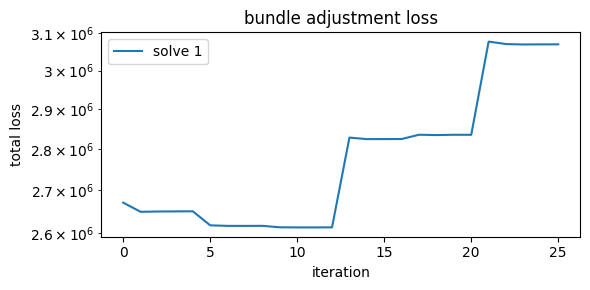

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))

for solve, history in enumerate(ba.loss_history):
    ax.plot(history, label=f"solve {solve + 1}")

ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("total loss")
ax.set_title("bundle adjustment loss")
ax.legend()
plt.tight_layout()

The color term is measured on a sample of pixels, redrawn a few times during the solve, with more
pixels at finer image scales. Each redraw adds terms, so the total jumps up; between jumps it
should fall and then flatten.

What changed: the final loss per term, the focal length, and the largest camera move as a share
of the path's size.

In [4]:
for term, loss in ba.losses.items():
    print(f"{term} loss: {loss:.4g}")

focal_before = ff_result.model_intrinsics[0, 0, 0]
focal_after = ba_result.model_intrinsics[0, 0, 0]
print(f"focal: {focal_before:.1f} -> {focal_after:.1f} px")

# Camera centers before and after, against the size of the camera path
ff_extrinsics = ff_result.extrinsics
ff_centers = invert_poses(ff_extrinsics)[:, :3, 3]
ba_centers = invert_poses(ba_result.extrinsics)[:, :3, 3]
path_size = np.linalg.norm(np.ptp(ff_centers, axis=0))
largest_move = np.linalg.norm(ba_centers - ff_centers, axis=1).max()
print(f"largest camera move: {largest_move / path_size:.1%} of the path size")

reprojection loss: 4.426e+05
depth loss: 1.799e+06
photometric loss: 8.283e+05
focal: 559.0 -> 556.7 px
largest camera move: 1.0% of the path size


Cameras before (grey) and after bundle adjustment (colored by time), over the refined points:

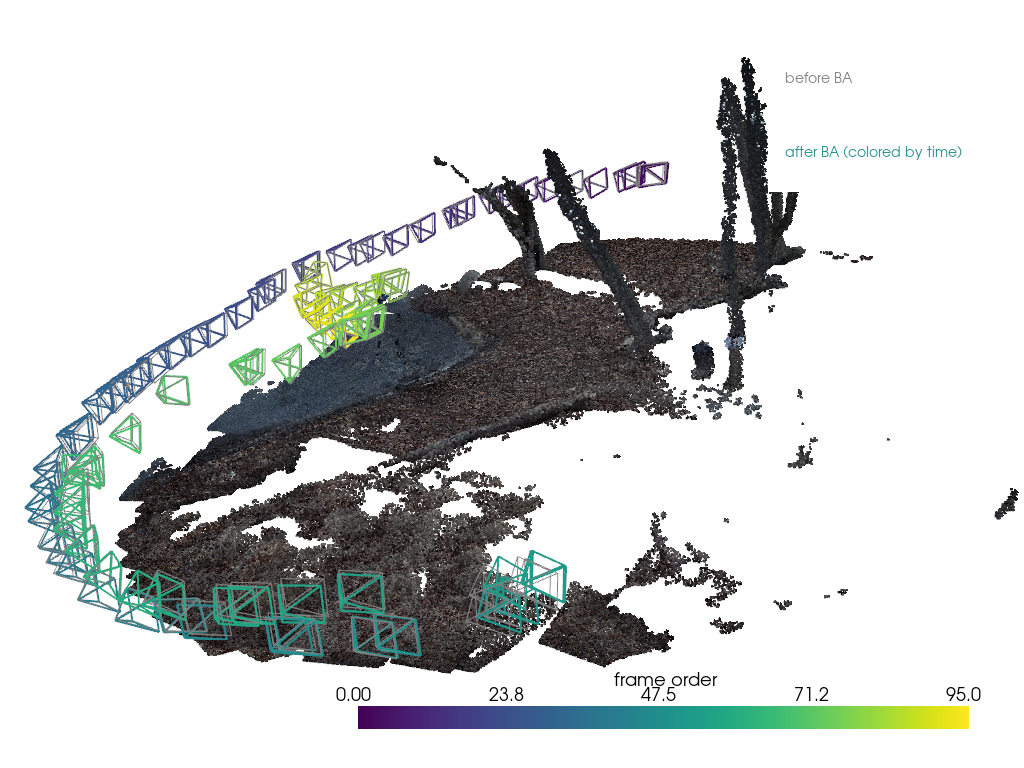

In [5]:
cloud = pointcloud_to_polydata(ba_result.points, RGB=ba_result.colors)
lo, hi = np.percentile(ba_result.points, [5, 95], axis=0)
scale = 0.005 * np.linalg.norm(hi - lo)

plotter = visualize_splat(
    cloud,
    ba_result.extrinsics,
    camera_kwargs={"scale": scale, "n_poses": 1, "line_width": 2},
    viz_kwargs=camera_view(ba_result.extrinsics, ba_result.points),
)

for w2c in ff_extrinsics:
    plotter.add_mesh(create_camera_frustum_pyvista(w2c, scale=scale), color="grey")

legend = [("before BA", "grey"), ("after BA (colored by time)", "#21918c")]
plotter.add_legend(legend, bcolor="white")
plotter.show()

On a short clip with a good first guess, the two camera sets sit almost on top of each other.

## 2. Loop closure

Loop closure runs the model on overlapping windows of frames instead of all frames at once.
Neighboring windows are joined through a shared frame. When the camera returns to a place it saw
before, a loop link is added, and the whole path is solved so it closes on itself. Bundle
adjustment runs inside each window.

Run loop closure with the scene's model:

In [6]:
# Free section 1's large arrays; the path plot needs only the feedforward cameras
del ff_result, ba_result, ba
pytorch_gc()

# The scene's feedforward model, built as the pointcloud stage builds it
creator = get_creator(pc["backend"])(
    max_points=pc["max_points"],
    clean=pc["clean"]["enabled"],
    **pc.get(pc["backend"], {}),
)
lc = LoopClosure(base=creator, config=LoopClosureConfig(), ba=BundleAdjustmentConfig(**terms))

# Hide per-window progress output
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    lc_result = lc.create_pointcloud(scene.images_dir, work / "loop_closure")

print(f"{len(lc_result.extrinsics)} frames in windows of {lc.config.submap_size}")
print(f"loops found: {getattr(lc, 'n_loops_applied', 0)}")

for record in lc.window_ba:
    print(f"window from frame {record['start']}: focal {record['focal']:.1f} px")

96 frames in windows of 20
loops found: 0
window from frame 0: focal 551.0 px
window from frame 20: focal 553.4 px
window from frame 40: focal 556.3 px
window from frame 60: focal 555.8 px
window from frame 80: focal 556.0 px


The camera path from one pass (grey) and from loop closure (red), seen from the side:

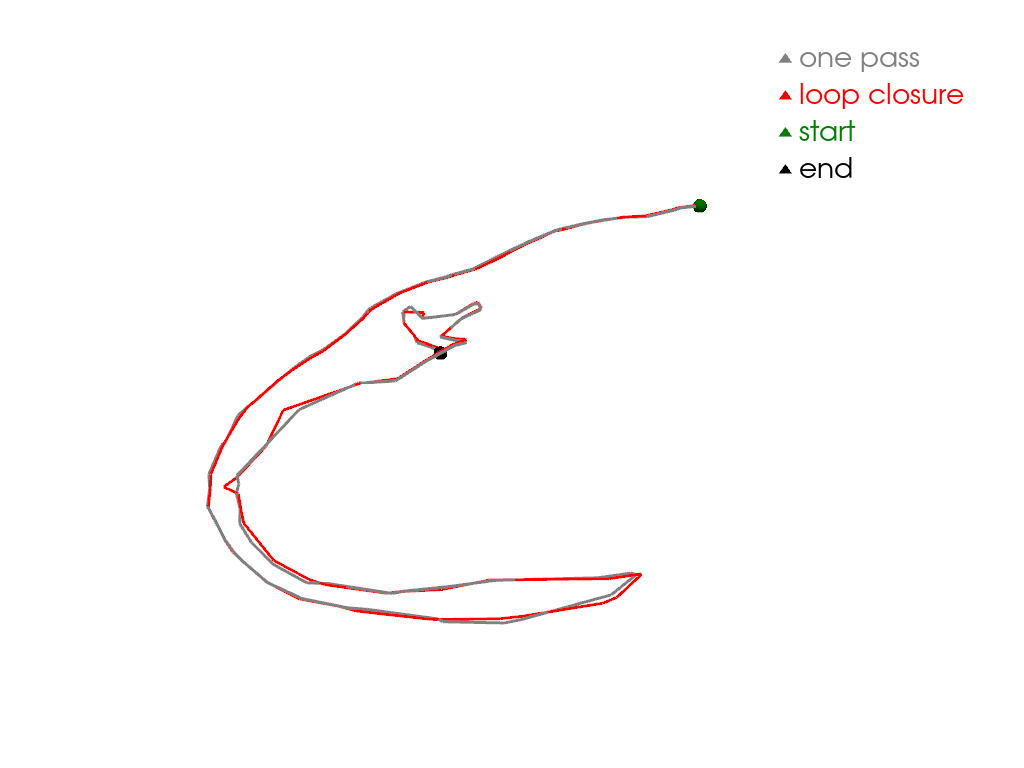

In [7]:
# Fit the loop-closure path onto the one-pass path (scale, rotation, shift)
lc_centers = invert_poses(lc_result.extrinsics)[:, :3, 3]
fit_scale, rotation, translation = umeyama_sim3(lc_centers, ff_centers)
lc_aligned = fit_scale * lc_centers @ rotation.T + translation

plotter = pv.Plotter()
plotter.add_mesh(pv.lines_from_points(ff_centers), color="grey", line_width=3, label="one pass")
plotter.add_mesh(pv.lines_from_points(lc_aligned), color="red", line_width=3, label="loop closure")

# Start and end of the path
for index, color, label in [(0, "green", "start"), (-1, "black", "end")]:
    plotter.add_points(
        ff_centers[[index]], color=color, point_size=14, render_points_as_spheres=True, label=label
    )

plotter.add_legend(bcolor="white")
apply_view(plotter, camera_view(ff_extrinsics, ff_centers))
plotter.show()

Each run has its own scale and origin, so the red path is fitted onto the grey one first. Where
a loop was found, the red path should remove drift toward the end.

## In a pipeline run

Bundle adjustment is on by default:

```yaml
pointcloud:
  bundle_adjustment:
    enabled: true
    track_source: xfeat                  # xfeat | loma | vggsfm
    track_kwargs: {seed_fraction: 1.0}   # track from every frame
```

It runs as the `refine` stage, which rewrites `pointcloud.zarr`. With
`loop_closure: {enabled: true}`, bundle adjustment runs inside each window instead.